In [1]:
%cd ..
from experiment_control.srs_microscope.srs_microscope import *

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1484: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("V_{srs} $(\mu V)$")
C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1864: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1866: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\experiment_control\experiment_control\srs_microscope\srs_microscope.py:1869: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")


C:\Users\euyehara\experiment_control


C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\cffi\cparser.py:436: UserWarning: #pragma in cdef() are entirely ignored. They should be removed for now, otherwise your code might behave differently in a future version of CFFI if #pragma support gets added. Note that '#pragma pack' needs to be replaced with the 'packed' keyword argument to cdef().
  warnings.warn(


Opening connnection to Keithley source meter
Opening connection to Agilent E3633A DC Power Supply
VOA initialized to 4.99 volt


In [6]:
center_spot()

In [5]:
cam.close()

In [11]:
VOA_volt = 5*u.V
ch_VOA.write(VOA_volt)

In [6]:
ramp_VCSEL(0*u.V)

In [ ]:
Vmon = (ch_HVA_Vmon.read())*100 

Hi


# Functions to test
    <!-- - find_raman() -->
    <!-- - HVA_to_wavelength() -->
    <!-- - parse_wav_delay() -->
    <!-- - ramp_VCSEL() -->
    <!-- - set_VCSEL_wavelength() -->
    - find_maxPos()
    
    

In [21]:
# def check_valid_wavelength(wavelength_set, wavvolt_file=wavvolt_file):
#     """
#     For Praevium VCSEL - Checks if set wavelength (scalar) is valid given the wavvolt tuning curve 
#     Returns bool 
#     """
#     # Load wavvolt_file
#     a = io.loadmat(wavvolt_file)
#     wav_calib = (a['peak_interp'][0] * u.m).to(u.nm)

#     valid = False
#     if (wavelength_set < np.min(wav_calib)) or (wavelength_set > np.max(wav_calib)) or (
#                     wavelength_set > wav_calib[0] and wavelength_set < wav_calib[-1]):
#         print(f"Wavelength out of range: {wavelength_set:3.2f}")
#     else: 
#         valid = True
#     return valid
    
# def HVA_to_wavelength(HVA_set, wavvolt_file=wavvolt_file):
#     # Given a HVA set (array or single voltage), find the VCSEL wavelength
#     a = io.loadmat(wavvolt_file) # Load wavvolt_file
#     wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
#     volt_calib = a['volt_interp'][0]*u.V
#     tol = 0.1*u.V

#     if np.isscalar(HVA_set.m):
#         HVA_set = np.array([HVA_set.m])*u.V
    
#     VCSEL_wav = np.zeros((1,HVA_set.shape[0]))

#     for i, volt in enumerate(HVA_set.to(u.V).m):
#         if np.min(np.abs(volt - volt_calib.m)) > tol.m:
#             raise ValueError("Voltage out of range)")
#         ind = np.argmin(np.abs(volt - volt_calib.m))
#         VCSEL_wav[i] = wav_calib[ind].to(u.nm).m
        
#     return VCSEL_wav * u.nm

# def set_VCSEL_wavelength(wavelength_set, wavvolt_file=wavvolt_file, delayvolt_file=delayvolt_file):
#     # Set VCSEL wavelength with VOA delay compensation - Use ramp_VCSEL instead (safer)
#     # Input - number with units
#     daq_HVset, VOA_Vset, HVA_Vset = parse_wav_delay(wavelength_set, wavvolt_file, delayvolt_file)
#     print(daq_HVset[0])
    
#     # Write daq voltages 
#     ch_VCSEL_MEMS.write(daq_HVset[0])
#     ch_VOA.write(VOA_Vset[0])


# def ramp_VCSEL(wav_or_V_set, ΔV=0.2*u.V):
#     # Gentler wavelength set - Reads current MEMS voltage, ramps VCSEL wavelength with delay compensation
#     # Input - wavelength or HVA voltage scalar with units
#     current_daqV = ch_VCSEL_MEMS.read()
#     current_VOAV = ch_VOA.read()
        
#     if wav_or_V_set.u == u.V:  # Set value given in volts
#         wav_or_V_set = HVA_to_wavelength(wav_or_V_set)[0]

#     daq_HVset, VOA_Vset, HVA_Vset = parse_wav_delay(wav_or_V_set, wavvolt_file, delayvolt_file)
#     daq_HVset = daq_HVset[0] # take out of array
#     VOA_Vset = VOA_Vset[0] # take out of array

#     # Generate array of daq voltages (VOA and HV) for ramp
#     if current_daqV == daq_HVset:
#         pass
#     else:
#         if current_daqV > daq_HVset: #ramp down
#             daq_HVarr = np.arange(current_daqV.to(u.V).m, daq_HVset.to(u.V).m, -ΔV.to(u.V).m)
#         elif current_daqV < daq_HVset:  #ramp up
#             daq_HVarr = np.arange(current_daqV.to(u.V).m, daq_HVset.to(u.V).m, ΔV.to(u.V).m)
#         daq_HVarr = daq_HVarr * u.V
#         daq_VOAarr = np.linspace(current_VOAV, VOA_Vset, daq_HVarr.shape[0])
#         # Ramp voltage 
#         for ind, volt in enumerate(daq_HVarr):
#             ch_VCSEL_MEMS.write(volt) 
#             ch_VOA.write(daq_VOAarr[ind])
#         #Final wavelength set (should be close, if not already there)
#         set_VCSEL_wavelength(wav_or_V_set)

# def parse_wav_delay(wavelength_set, wavvolt_file=wavvolt_file, delayvolt_file=delayvolt_file):
#     # Given input wavelength(s), return corresponding MEMS and VOA voltages, daq set to HVA for MEMS voltage
#     # Input: array or scalar (with units), sort array by increasing MEMS voltage
#     a = io.loadmat(wavvolt_file) # Load wavvolt_file
#     wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
#     volt_calib = a['volt_interp'][0]*u.V

#     b = io.loadmat(delayvolt_file) # Load delayvolt_file
#     VOA_volt = b['VOA_est_interp'][0]*u.V
#     VCSEL_volt = b['V_MEMSinterp'][0]*u.V 

#     # If input scalar, put into array
#     if np.isscalar(wavelength_set.m):
#         wavelength_set = np.array([wavelength_set.m])*u.nm

#     # Initialize arrays
#     VOA_Vset = [] # VOA Voltage
#     HVA_Vunsort = np.zeros(wavelength_set.shape) # Discontinuous MEMS voltage from linear wavelength sweep
#     daq_HVset = np.zeros(wavelength_set.shape) # MEMS Voltage (input to HVA)

#     # Map wavelength to HVA voltage (VCSEL MEMS)
#     for i, wav in enumerate(wavelength_set):
#         if check_valid_wavelength(wav, wavvolt_file):
#             ind = np.argmin(np.abs(wav - wav_calib))
#             HVA_Vunsort[i] = volt_calib[ind].to(u.V).m
#         else:
#             raise ValueError("Set value outside range")
#     Vsort_ind = np.argsort(HVA_Vunsort)
#     HVA_Vset = HVA_Vunsort[Vsort_ind] * u.V
#     wav_sort = wavelength_set[Vsort_ind]

#     # Scale HVA voltage to daq output voltage
#     for i, HVA_volt in enumerate(HVA_Vset):
#         daq_HVset[i] = HVA_to_daq(HVA_volt).to(u.V).m
#     daq_HVset = daq_HVset * u.V

#     # Find VOA voltage corresponding to VCSEL MEMS voltage set
#     for volt in HVA_Vset.to(u.V):
#         ind1 = np.argmin(np.abs(volt.m - VCSEL_volt.to(u.V).m))
#         VOA_Vset.append(VOA_volt[ind1].to(u.V).m)
#     VOA_Vset = VOA_Vset * u.V
        
#     return daq_HVset, VOA_Vset, HVA_Vset


# def generate_valid_sweep(wav_start, wav_stop, Δwav, wavvolt_file=wavvolt_file):
#     """
#     For Praevium VCSEL - Checks start and stop wavelengths and generates array of valid wavelengths (omits middle gap)
#     """
#     # Generate linear array of nominal wavelengths
#     wl_arr = np.arange(wav_start.to(u.nm).m, wav_stop.to(u.nm).m + Δwav.to(u.nm).m, Δwav.to(u.nm).m) * u.nm
#     valid_wl_arr = []

#     for wl in wl_arr:
#         if check_valid_wavelength(wl, wavvolt_file=wavvolt_file):
#             valid_wl_arr.append(wl.m)
#         else:
#             pass

#     return valid_wl_arr * u.nm

# def find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, Δwav=0.1*u.nm, num_sweep=10, figsize=(5,6), wavvolt_file=wavvolt_file, delayvolt_file=delayvolt_file, wavvolt_HVCALIB=wavvolt_HVCALIB):
#     """
#     Given nominal raman peak (cm^-1), sweep in neighborhood of peak, extract exact voltage of peak location, set voltage to peak
#     """
#     remove_bs()

#     # Assign pump and Stokes wavelengths
#     pump_wav = fixed_wav
    
#     # Nominal peak wavelength
#     pump_wav = fixed_wav
#     stokes_pk = 1 / (1/pump_wav - raman_pk)
#     wav_stop = 1 / (1/pump_wav - (raman_pk + np.round(sweep_bw / 2)))
#     wav_start = 1 / (1/pump_wav - (raman_pk - np.round(sweep_bw / 2)))
    
#     # Create array of valid wavelengths
#     wavelength_set = generate_valid_sweep(wav_start, wav_stop, Δwav, wavvolt_file)
#     stokes_wav = wavelength_set
#     raman_shift = (1 / pump_wav  - 1 / stokes_wav).to(1 / u.cm)

#     # Configure HVA and VOA for sweep
#     daq_HVset, VOA_Vset, HVA_Vset = parse_wav_delay(wavelength_set, wavvolt_file, delayvolt_file)
#     V_MEMS_sweep = configure_VCSEL_sweep(daq_HVset, num_sweep)
#     V_VOA_sweep = configure_VCSEL_sweep(VOA_Vset, num_sweep)
    
#     num_samp = V_VOA_sweep.shape[0]
#     fsamp = (1 / (4 * t_lia)).to(u.Hz)

#     #Initialize to first voltages in sweep
#     ramp_VCSEL(HVA_Vset[0])

#     write_data = {
#         ch_VCSEL_MEMS_str: V_MEMS_sweep,
#         ch_VOA_str: V_VOA_sweep
#     }
#     # Create DAQ task
#     sweep_task = Task(
#         ch_Vsrs_2,
#         ch_HVA_Vmon,
#         ch_VCSEL_MEMS,
#         ch_VOA
#     )
#     # Set DAQ sampling rate and number of samples to write/read (for averaging)
#     sweep_task.set_timing(fsamp=fsamp, n_samples=num_samp)

#     # Print calculated sweep time
#     sweep_time = (1 / fsamp).to(u.second) * num_samp
#     start_time = time.time()
#     end_time = start_time + sweep_time.m
#     print(f"sweep time: {sweep_time:3.2f}")
#     print(f"start time: {time.ctime(start_time):s}")
#     print(f"stop time: {time.ctime(end_time):s}")

#     read_data = sweep_task.run(write_data)
#     proc_data = unwrap_sweep(read_data, num_sweep, wavelength_set, wavvolt_HVCALIB)

#     # Calculate raman shift
#     raman_shift = raman_shift[:-1]
#     offset = 0*u.V
#     Vsrs_arr = (proc_data["Vsrs_arr"] / 10 + offset).to(u.V).m * sens_lia.to(u.V)

#     Vsrs_raw_av = np.mean(Vsrs_arr, axis=0)
#     mind = np.argmax(Vsrs_raw_av)
#     HV_raw_av = np.mean(proc_data["HV_arr"], axis=0)
#     HV_pk = HV_raw_av[mind]

#     # Unreserve daq
#     sweep_task.unreserve()

#     # Set voltage to peak location
#     ramp_VCSEL(HV_pk)

#     Vsrs_interp_arr = calibrate_sweepSpectra(wavelength_set[:-1], Vsrs_arr[:,:-1], proc_data["HV_arr"][:,:-1], HVA_Vset[:-1], wavvolt_HVCALIB)
#     print(Vsrs_interp_arr.shape)
#     Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
#     mind = np.argmax(Vsrs_av)
#     print("Peak at {:2.3f}".format(raman_shift[mind]))
#     print("LIA voltage: {:2.3f}".format(Vsrs_raw_av[mind]))
#     print("Stokes wavelength: {:2.3f}".format(wavelength_set[mind]))
#     print("MEMS voltage at {:2.3f}".format(HV_pk))
    
#     fig, ax = plt.subplots(1, 1, figsize=figsize)
#     ax.plot(raman_shift, Vsrs_av.to(u.uV))
#     ax.set_xlabel("Raman Shift $(cm^{-1})$")
#     ax.set_ylabel("V_{srs} $(\mu V)$")

# def calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HV_arr, HVA_Vset, wavvolt_HVCALIB=wavvolt_HVCALIB):
#     """
#     Calibrate daq VCSEL sweep using HVA monitor.  Return calibrated Vsrs_interp_arr (wavelength interpolated to original wavelength set for consistent
#     Raman shifts between iterations)
#     """
#     def line(x,a,b):
#         return a*x + b
    
#     # Calibrate voltage to wavelength
#     a = io.loadmat(wavvolt_HVCALIB)
#     wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
#     volt_calib = a['volt_interp'][0]*u.V

#     # Initialize arrays
#     HV_filt = np.array(np.zeros(HV_arr.shape))
#     wav_calib_arr = np.array(np.zeros(HV_arr.shape))
#     Vsrs_interp_arr = np.array(np.zeros(HV_arr.shape))
        
#     for spec in range(HV_arr.shape[0]):
#         popt,_ = curve_fit(line,HVA_Vset.to(u.V).m,HV_arr[spec].to(u.V).m)
#         HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
#     HV_filt = HV_filt*u.V 
    
#     # Find wavelengths corresponding to measured voltage 
#     for sweep_iter in range(HV_filt.shape[0]):
#         for wl in range(HV_filt.shape[1]):
#             ind = np.argmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
#             wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
            
#         # Interpolate wavelength vs spectra to uniformly sample in wavelength
#         Vsrs_interp_arr[sweep_iter,:] = np.interp(wavelength_set.to(u.nm).m, wav_calib_arr[sweep_iter,:], Vsrs_arr[sweep_iter,:].m)
    
#     return Vsrs_interp_arr*u.V

<>:226: SyntaxWarning: invalid escape sequence '\m'
<>:226: SyntaxWarning: invalid escape sequence '\m'
C:\Users\euyehara\AppData\Local\Temp\ipykernel_6184\2149847547.py:226: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("V_{srs} $(\mu V)$")


sweep time: 11.80 second
start time: Thu May 29 00:35:49 2025
stop time: Thu May 29 00:36:00 2025
(6, 48)
Peak at 1325.088 / centimeter
LIA voltage: -0.000 volt
Stokes wavelength: 1254.383 nanometer
MEMS voltage at 61.079 volt


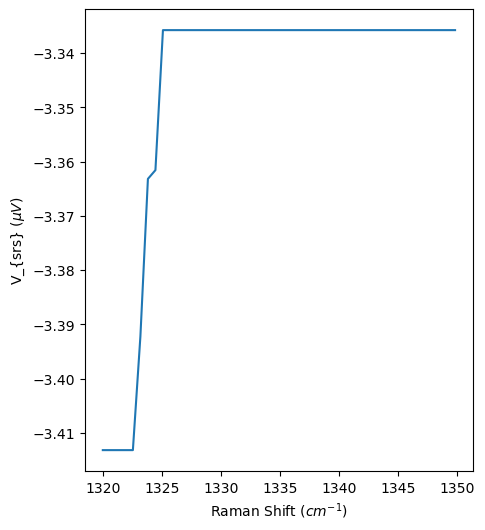

In [24]:
raman_pk = 1335/u.cm
sweep_bw = 30 /u.cm
t_lia = 10*u.ms
sens_lia = 300*u.uV
fixed_wav = 1075.6*u.nm
find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, num_sweep=3)


In [184]:
wavelength_set = np.array([1230, 1260, 1250])*u.nm
daq_HVset, VOA_Vset, HVA_Vset = parse_wav_delay(wavelength_set)
print(daq_HVset)
print(VOA_Vset)
print(HVA_Vset)

Wavelength out of range: 1230.00 nanometer
[0.0 6.170654552042253 7.243133265513733] volt
[2.15 1.4969385810491072 1.0] volt
[0.0 55.35 64.97] volt


In [41]:
def generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=None, name=None, delayvolt_file=delayvolt_file):
    """
    Sweeps daq2 + HVA voltages to generate VCSEL tunings curve, reads OSA spectrum
    :param: 
        - voltage_list - list of VCSEL voltages
        - osa_settings - dict of RBW, wav_start, wav_stop, ref_level
        - num_avg - # of voltage reads to average
    :return: ds
    """
     # Load delayvolt_file
    # b = io.loadmat(delayvolt_file)
    # VOA_volt = b['VOA_est_interp'][0]*u.V
    # VCSEL_volt = b['V_MEMSinterp'][0]*u.V 

    # # Find VOA voltage corresponding to VCSEL MEMS voltage set
    # for volt in voltage_list.to(u.V):
    #     ind1 = np.argmin(np.abs(volt.m - VCSEL_volt.to(u.V).m))
    #     VOA_Vset.append(VOA_volt[ind1].to(u.V).m)
    # VOA_Vset = VOA_Vset * u.V

    # num_samp = V_VOA_sweep.shape[0]

    #Initialize to first voltages in sweep
    # ch_VCSEL_MEMS.write(V_MEMS_sweep[0])
    # ch_VOA.write(V_VOA_sweep[0])
    ramp_VCSEL(voltage_list[0])

    #Specify location of data save
    sample_dir = resolve_sample_dir(sample_dir, data_dir=calib_dir)
    fpath = new_path(name=name,data_dir=sample_dir,ds_type='wavvoltdata',extension='h5',timestamp=True)
    print("saving data to: ")
    print(fpath)

    # Configure OSA
    osa = instrument("hp_osa", reopen_policy='reuse')
    osa.set_resolution_bandwidth(osa_settings["rbw"])
    osa.set_reference_level(osa_settings["ref_level"])
    span = osa_settings["wav_stop"] - osa_settings["wav_start"]
    center_wl = np.round(span/2) + osa_settings["wav_start"]
    osa.set_wavelength_span(span)
    osa.set_center_wavelength(center_wl)
    
    # sweep_time = osa.get_sweep_time()
    wavelength, _ = osa.get_spectrum()
    trace_len = wavelength.shape[0]
    
    # Initialize lists for data save
    meas_volt_list = []
    pk_wl_list = []
    spectrum_array = np.array(np.zeros((len(voltage_list), int(trace_len))))

    # Sweep power supply voltage and get osa trace
    for ind, volt in enumerate(voltage_list):
        print('Voltage set: %.4f V...' % volt.to(u.V).m)
        # Set the voltage
        ramp_VCSEL(volt)
        # ch_VCSEL_MEMS.write(HVA_to_daq(volt))
        # ch_VOA.write(V_VOA_sweep[0])

        # Wait [s]
        time.sleep(1.5)
        meas_volt_rep = []
        for iter in range(num_avg):
            meas_volt = Vmon_to_HVA(ch_HVA_Vmon.read())
            # time.sleep(0.3)
            meas_volt_rep.append(meas_volt.to(u.V).m) #[V]
        # print(meas_volt_rep)
        meas_volt_list.append(np.mean(meas_volt_rep)) #[V]
        print('Voltage measured: %0.4f V' % meas_volt_list[ind])
        
        # Wait [s]
        # time.sleep(0.5)
        # time.sleep(sweep_time.m)

        #Read osa spectrum and store in wavelength_array
        _, spectra = osa.get_spectrum()
        # time.sleep(sweep_time.m)
        spectrum_array[ind, :] = np.reshape(spectra, (1, int(trace_len)))
        pk_ind = np.argmax(spectrum_array[ind,:])
        pk_wl_list.append(wavelength[pk_ind].to(u.m).m)
    spectrum_array = spectrum_array * u.dimensionless
    meas_volt_list = meas_volt_list * u.V
    pk_wl_list = pk_wl_list * u.m
    
    print(np.shape(spectrum_array))
    print('Finished voltage sweep')
    print('-----------------------------')
    dump_hdf5(osa_settings, fpath, open_mode='x')
    wavvolt_data = {
         'num_avg': num_avg,
         'voltage_list': voltage_list,
         'meas_volt_list': meas_volt_list,
         'pk_wl_list': pk_wl_list,
         'spectrum_array': spectrum_array,
         'wavelength': wavelength
         }
    dump_hdf5(wavvolt_data, fpath)

    ds = load_hdf5(fpath=fpath)

    # Save spectrum data to .mat file
    mat_fname = fpath[:-2] + 'mat'
    file_dir = os.path.join(sample_dir, mat_fname)
    data = {
            'rbw': osa_settings['rbw'].to(u.m).m,
            'ref_level': osa_settings['ref_level'].m,
            'num_avg': num_avg,
            'voltage_list': voltage_list.to(u.V).m,
            'spectrum_array': spectrum_array.m,
            'wavelength': wavelength.to(u.m).m,
            'meas_volt_list': meas_volt_list.to(u.V).m,
            'pk_wl_list': pk_wl_list.to(u.m).m
            }
    io.savemat(file_dir, data)

    # Save wavvolt file
    # wavvolt_filename = os.path.join(sample_dir, "wavvolt_" + name)
    # save_wavvolt(name, np.array(meas_volt_list), np.array(pk_wl_list))
    return ds

In [44]:
VOA_volt = 5*u.V
ch_VOA.write(VOA_volt)

In [43]:
ramp_VCSEL(0*u.V)
# HVA_to_wavelength(86*u.V)

# Collect Wavvolt

In [42]:
sample_dir = "dev1b_GS-SS"
name = "GSdev1bBOA700mA_delayvolt10_0-88.1V"

init_voltage = 0*u.V  # [V]
end_voltage = 88*u.V # [V]
increment = 1*u.V  # Voltage increment
voltage_list = np.arange(init_voltage.m, end_voltage.m+increment.m, increment.m) #* u.V
voltage_list = np.concatenate((voltage_list, [88.1]))*u.V
osa_settings = {
    "rbw": 0.1*u.nm,
    "ref_level": -10*u.dimensionless,
    "wav_start": 1230*u.nm,
    "wav_stop": 1360*u.nm
}
num_avg=5

ramp_VCSEL(0*u.V) #turn on
ds=generate_wavvolt(voltage_list, osa_settings, num_avg, sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\experiment_control\calibration_data\VCSEL_calibration\Sample_dev1b_GS-SS_2025-05-29-01-16-40\wavvoltdata_GSdev1bBOA700mA_delayvolt10_0-88.1V_2025-05-29-01-46-11.h5
Voltage set: 0.0000 V...
Voltage measured: -0.3322 V


C:\Users\euyehara\AppData\Local\Temp\ipykernel_27524\4128767897.py:78: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  spectrum_array[ind, :] = np.reshape(spectra, (1, int(trace_len)))


Voltage set: 1.0000 V...
Voltage measured: -0.2806 V
Voltage set: 2.0000 V...
Voltage measured: 1.7317 V
Voltage set: 3.0000 V...
Voltage measured: 1.7317 V
Voltage set: 4.0000 V...
Voltage measured: 1.7252 V
Voltage set: 5.0000 V...
Voltage measured: 1.7317 V
Voltage set: 6.0000 V...
Voltage measured: -0.2806 V
Voltage set: 7.0000 V...
Voltage measured: -0.1129 V
Voltage set: 8.0000 V...
Voltage measured: -0.2742 V
Voltage set: 9.0000 V...
Voltage measured: 8.6586 V
Voltage set: 10.0000 V...
Voltage measured: 8.6909 V
Voltage set: 11.0000 V...
Voltage measured: 10.6774 V
Voltage set: 12.0000 V...
Voltage measured: 11.6706 V
Voltage set: 13.0000 V...
Voltage measured: 11.6642 V
Voltage set: 14.0000 V...
Voltage measured: 13.6829 V
Voltage set: 15.0000 V...
Voltage measured: 14.6890 V
Voltage set: 16.0000 V...
Voltage measured: 15.6565 V
Voltage set: 17.0000 V...
Voltage measured: 16.6497 V
Voltage set: 18.0000 V...
Voltage measured: 17.6623 V
Voltage set: 19.0000 V...
Voltage measured:

In [38]:
fname = "wavvoltdata_GSDev1a_9.0mW_0-65V_2025-04-18-22-34-54.h5"
sample_dir = calib_dir
dir_name ="Sample_Dev1a_GS_2025-03-29-17-59-42"
fpath = os.path.join(sample_dir, dir_name)
ds = load_data_from_file(fpath, fname)

loading file: wavvoltdata_GSDev1a_9.0mW_0-65V_2025-04-18-22-34-54.h5
importing meas_volt_list...
importing pk_wl_list...
importing spectrum_array...
importing voltage_list...
importing wavelength...
importing attr num_avg...
importing attr rbw...
nanometer
importing attr rbw_units...
importing attr ref_level...
dimensionless
importing attr ref_level_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...


C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


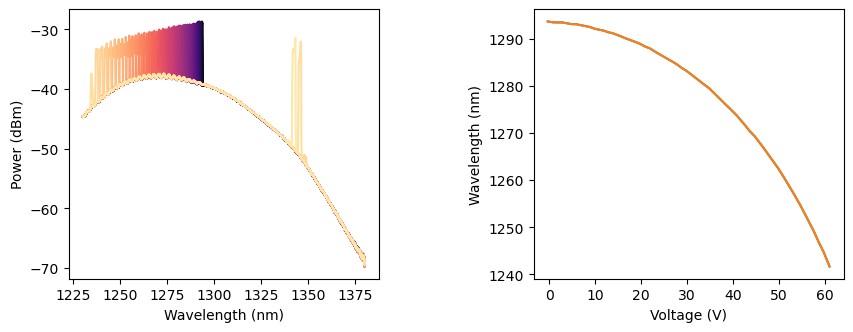

In [39]:
name="GSdev1b_delayvolt10"
sample_dir=calib_dir
volt_stop=88.6*u.V
smooth_param=None

save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=None,sample_dir=None)
# save_wavvolt(ds, volt_stop=volt_stop, smooth_param=smooth_param, name=name,sample_dir=sample_dir)

# Raman Peak Search

In [77]:
# Find Raman Peak
raman_pk = 1335/u.cm
sweep_bw = 20 /u.cm
t_lia = 1*u.ms
sens_lia = 1*u.mV
fixed_wav = 1075.7*u.nm
Δwav = 0.1*u.nm 
num_sweep = 10

find_raman(raman_pk, sweep_bw, t_lia, sens_lia, fixed_wav, Δwav, num_sweep)
    

1256.080655861633 nanometer
1257.6603787350057 nanometer
1254.50489652842 nanometer


# DAQ Continuous Sweep

In [8]:
sample_dir = 'GSDev1a_inline'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'diamondCarotene_IPA_diamond2_02nm'

t_lia = 1*u.ms
sens_lia = 1 * u.mV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.1*u.nm 
num_sweep = 5
fixed_wav = 1075.7*u.nm

ds = VCSEL_sweep_spectrum(wav_start, wav_stop, Δwav, num_sweep, t_lia, sens_lia, fixed_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_GSDev1a_inline_2025-04-13-23-54-26\Spectra_diamondCarotene_IPA_diamond2_02nm_2025-04-18-01-12-54.h5
dumping item: num_sweep
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
millivolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wavelength_set
dumping item: pump_wav
non-array, non-list item with units:
nanometer
sweep time: 7.60 second
start time: Fri Apr 18 01:12:54 2025
stop time: Fri Apr 18 01:13:02 2025
dumping item: Dev2/ao1
dumping item: Dev2/ao0
dumping item: Dev2/ai0
dumping item: Dev2/ai1
dumping item: t
dumping item: Vsrs_arr
dumping item: HV_arr
dumping item: wav_est_arr
dumping item: Vsrs_interp_arr
dumping item: H

Peak at 1334.489 / centimeter


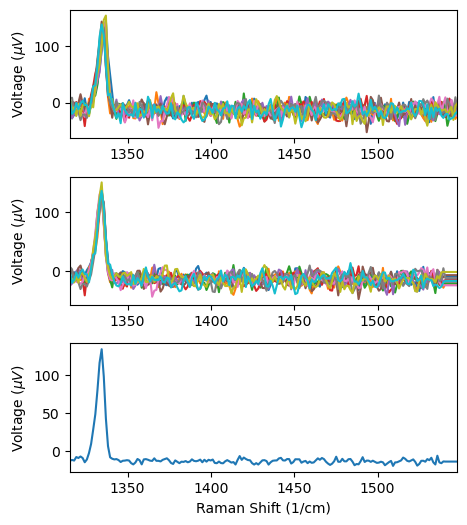

In [9]:
fpath = os.path.join(data_dir,"Sample_GSDev1a_inline_2025-04-13-23-54-26")
fname = name 
fig = plot_daq_sweepSpectra(ds, fname=fname, fpath=fpath)

In [213]:
sample_dir = "GSDev1a_inline"
filename = "Spectra_findDiamond_2025-03-31-20-25-07.h5"
ds = load_data_from_file(sample_dir, filename)
wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_GSDev1a_9.2mW_2025-3-31.mat") #For post-acquisition wavelength calibration

loading file: Spectra_findDiamond_2025-03-31-20-25-07.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_interp_arr...
importing raman_shift...
importing t...
importing wav_est_arr...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


def plot_daq_sweepSpectra(ds, fname, fpath=False, figsize=(5,6), wavvolt_HVCALIB=wavvolt_HVCALIB):
    """
    Plot daq continuous sweep spectra. 3 Subplots: (1) Raw spectra, (2) Wavelength corrected from measured voltages, (3) Averaged corrected
    """
    def line(x,a,b):
        return a*x + b

    #Remove first point in sweep
    HVA_Vset = ds["HVA_Vset"][:-1]
    wavelength_set = ds["wavelength_set"][:-1]
    HV_arr = ds["HV_arr"][:,:-1]
    raman_shift = ds["raman_shift"][:-1]
    offset = 0*u.V
    Vsrs_arr = (ds["Vsrs_arr"][:,:-1] / 10 + offset).to(u.V).m * ds["sens_lia"].to(u.V)
    HV_filt = np.array(np.zeros(HV_arr.shape))
    wav_calib_arr = np.array(np.zeros(HV_arr.shape))
    Vsrs_interp_arr = np.array(np.zeros(HV_arr.shape))
    
    for spec in range(HV_arr.shape[0]):
        popt,_ = curve_fit(line,HVA_Vset.to(u.V).m,HV_arr[spec].to(u.V).m)
        HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
    HV_filt = HV_filt*u.V 
    
    # Calibrate voltage to wavelength
    a = io.loadmat(wavvolt_HVCALIB)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    # Find wavelengths corresponding to measured voltage 
    for sweep_iter in range(HV_filt.shape[0]):
        for wl in range(HV_filt.shape[1]):
            ind = np.argmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
            wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
            
        # Interpolate wavelength vs spectra to uniformly sample in wavelength
        Vsrs_interp_arr[sweep_iter,:] = np.interp(wavelength_set.to(u.nm).m, wav_calib_arr[sweep_iter,:], Vsrs_arr[sweep_iter,:].m)
    Vsrs_interp_arr = Vsrs_interp_arr*u.V
    Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
    mind = np.argmax(Vsrs_av)
    print("Peak at {:2.3f}".format(raman_shift[mind]))
    
    fig, ax = plt.subplots(3, 1, figsize=figsize, gridspec_kw={"wspace":0,"hspace":0.3})
    for spec in range(Vsrs_arr.shape[0]):
        ax[0].plot(raman_shift, Vsrs_arr[spec].to(u.uV))
        ax[1].plot(raman_shift, Vsrs_interp_arr[spec].to(u.uV))
        # ax[3].plot(HVA_Vset, HV_arr[spec].to(u.V))
        # ax[3].plot(HVA_Vset, HV_filt[spec].to(u.V))
    ax[2].plot(raman_shift, Vsrs_av.to(u.uV))
    ax[0].set_ylabel("Voltage $(\mu V)$")
    ax[0].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    ax[1].set_ylabel("Voltage $(\mu V)$")
    ax[1].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    ax[2].set_xlabel("Raman Shift (1/cm)")
    ax[2].set_ylabel("Voltage $(\mu V)$")
    ax[2].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))

    if fpath:
        fname=os.path.normpath(os.path.join(fpath,fname))
        plt.savefig(fname, dpi=None, facecolor=None, edgecolor=None,
            orientation='portrait', transparent=True, bbox_inches=None, pad_inches=0.5)
    return fig

fname = "Spectra_findDiamond_2025-03-31-20-25-07"
fpath = os.path.join(data_dir,sample_dir)
fig = plot_daq_sweepSpectra(ds, fname, fpath=fpath)



# DAQ Sw

# DAQ Step Sweep

In [11]:
osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

In [16]:
#Test DAQ VCSEL step sweep
sample_dir = 'Test_DAQ_VCSEL_sweep'
# name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'
name = 'testGS_sweep_MM_full'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 1*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm

calib_dir = 'C:\\Users\\euyehara\\experiment_control\\calibration_data\\VCSEL_calibration\\'
wavvolt_file = calib_dir + 'wavvolt-trunc_Dev1a_25C_OEland1076_5.72mW_2025-3-17.mat'
delayvolt_file = calib_dir + 'delayvolt3.mat'


ds = VCSEL_step_spectrum(osa, wavvolt_file, delayvolt_file, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)
# ds = VCSEL_step_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=1*u.s,sample_dir=sample_dir, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_DAQ_VCSEL_sweep_2025-03-25-18-27-43\Spectra_testGS_sweep_MM_full_2025-03-26-19-07-01.h5
dumping item: num_avg
non-array, non-list item without units
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: Δwav
non-array, non-list item with units:
nanometer
dumping item: wav_settle_time
non-array, non-list item with units:
second
dumping item: wavelength_set
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 60.80 second
start time: Wed Mar 26 19:07:11 2025
stop time: Wed Mar 26 19:08:12 2025
dumping item: spec
dumping item: daq_Vset
dumping item: HVA_Vset
dumping item: VOA_Vset
dumping item: V_mon
dumping item: raman_shift
dumping item: pump_wl_

# Single Wavelength Measurement

In [191]:
sample_dir = "PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point"
# name = "R_ycut-LN_DSP_Y(cZ)Y_30ms3uV_O110mW_S27mW_986"
name = "VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV"
# name = "OElandSweep_T_30ms3uV_120s_985_HWP_SHG-LP_50mW_noF-F"

t_lia = 3*u.ms
n_rep = 50
pump_wav = 1072.6*u.nm
stokes_wav = 1251.7*u.nm

ds_point = acquire_point(t_lia, n_rep, pump_wav, stokes_wav, sample_dir=sample_dir, name=name)


saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_PhotonicsWest-SNR-LIAnoiseMeas_diamond_SRL_point_2024-12-14-21-35-34\WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: pump_wav
non-array, non-list item with units:
nanometer
dumping item: stokes_wav
non-array, non-list item with units:
nanometer
acquisition time: 600.00 millisecond
start time: Sun Dec 15 16:39:49 2024
stop time: Sun Dec 15 16:49:49 2024
dumping item: srs
loading file: WavePoint_VaryDev1a_noise_SA-230F5_FGA21-25V_OE60mW_Dev1a0mW_3ms100uV_2024-12-15-16-39-49.h5
importing srs...
importing attr fsamp...
hertz
importing attr fsamp_units...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr stokes_wav...
nanometer
importing attr stokes_wav_units...
importing attr t_lia...
millisecond


# Source Meter Step Sweep

osa = initialize_osa(ref_level = -43*u.dimensionless, wav_start=1050*u.nm, wav_stop = 1300*u.nm)

[pk_wls, _] = osa.get_peak_info()
print(pk_wls[0])
print(pk_wls[1])

In [5]:
span = 1300*u.nm - 1230*u.nm
center_wl = np.round(span/2) + 1250*u.nm
osa.set_wavelength_span(span)
osa.set_center_wavelength(center_wl)

sample_dir = 'Test_VCSEL_sweep'
name = 'diamond_sweep_VOA_wavvolt-trunc_OE71mW_Dev1a8.5mW_best'

t_lia = 30*u.ms
sens_lia = 300 * u.uV
wav_start = 1253*u.nm
wav_stop = 1290*u.nm
Δwav = 0.2*u.nm 
wav_settle_time = 0.3*u.s
num_avg = 5
fixed_wav = 1075.6*u.nm


ds_spec = acquire_spectrum(osa, num_avg, t_lia, sens_lia, wav_start, wav_stop, Δwav, fixed_wav, wav_settle_time=wav_settle_time, sample_dir=sample_dir, name=name)


fig=plot_spectra(ds_spec, sg_win_len=10)


plt.figure()
ind_arr = np.arange(0, s_wl.shape[0],1)
s_wl = savgol_filter(ds_spec["stokes_wl_meas"].m, 15,2)*u.m
plt.plot(ind_arr,s_wl)

# Continuous Sweep Spectrum (OE Land sweep)

In [10]:
sample_dir2 = "Test_VCSEL_sweep_CW"
name = "findDiamondsig"

t_lia = 10*u.ms
sens_lia = 100*u.uV
t_sweep = 120*1*u.s
wav_start = 1037.9*u.nm
wav_stop = 1080*u.nm
fixed_wav = 1256.4*u.nm
ds_spec = continuous_spectrum(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)
# ds_spec = continuous_spectrum_tap(t_lia, sens_lia, wav_start, wav_stop, fixed_wav, t_sweep=t_sweep,sample_dir=sample_dir2, name=name)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04\SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
dumping item: t_lia
non-array, non-list item with units:
millisecond
dumping item: sens_lia
non-array, non-list item with units:
microvolt
dumping item: fsamp
non-array, non-list item with units:
hertz
dumping item: wav_start
non-array, non-list item with units:
nanometer
dumping item: wav_stop
non-array, non-list item with units:
nanometer
dumping item: t_sweep
non-array, non-list item with units:
second
dumping item: fixed_wav
non-array, non-list item with units:
nanometer
sweep time: 120.00 second
start time: Mon Mar 31 19:35:48 2025
stop time: Mon Mar 31 19:37:48 2025
dumping item: spec
dumping item: wav_mon
loading file: SpectraSweep_findDiamondsig_2025-03-31-19-35-48.h5
importing spec...
importing wav_mon...
importing attr fixed_wav...
nanometer
importing attr fixed_wav_units...
importing attr fsamp...
hertz
importing a

# Knife Edge Scan

In [4]:
cam.close()
stage = initialize_stage()
stage.connect()

Connecting to BPC203:
	- connecting to controller 71829423 --> done
	- connecting channel 1 (x axis) --> done
	- connecting channel 2 (y axis) --> done
	- connecting channel 3 (z axis) --> done




In [3]:
wf_illum_off()

In [5]:
pos = stage.get_axis_position('y')

In [79]:
stage.set_axis_position('y', 7)

	- moving y axis piezo to 7.000000 um --> done


In [90]:
stage.set_axis_position('y', 15)

	- moving y axis piezo to 15.000000 um --> done


In [91]:
stage.set_axis_position('y', 0)

	- moving y axis piezo to 0.000000 um --> done


σ = 1.33μm


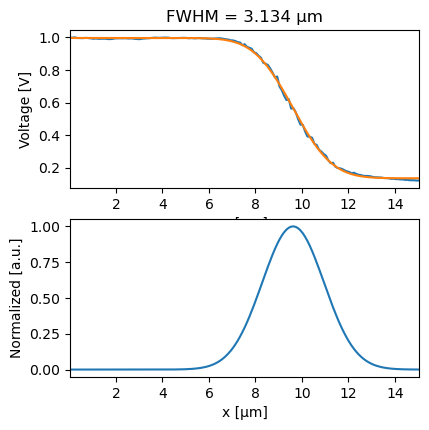

In [117]:
fig = plot_knife_scan(ds_spot)

In [116]:
scan_length = 15*u.um
axis = 'y'
step_size = 0.1*u.um
num_avg  = 3
# [ps_arr, pd_arr] = scan_single_axis(scan_length, axis, step_size, wait=0.5*u.s)
# ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='Nikon20xR_y_SiAu', name='Solstis985_pos38')
ds_spot = knife_edge_scan(stage, scan_length, axis, step_size, num_avg=num_avg, sample_dir='BeamSpotMeas_Nikon20xT_y_GaAs', name='Dev1a-redo_Coverslip_pos47')

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_BeamSpotMeas_Nikon20xT_y_GaAs_2024-12-14-12-14-28\knifeScan_Dev1a-redo_Coverslip_pos47_2024-12-14-17-53-04.h5
15.033570360423598
scan time: 302.00 second
start time: Sat Dec 14 17:53:04 2024
stop time: Sat Dec 14 17:58:06 2024
	- moving y axis piezo to 0.033570 um --> done
	- moving y axis piezo to 0.133570 um --> done
	- moving y axis piezo to 0.233570 um --> done
	- moving y axis piezo to 0.333570 um --> done
	- moving y axis piezo to 0.433570 um --> done
	- moving y axis piezo to 0.533570 um --> done
	- moving y axis piezo to 0.633570 um --> done
	- moving y axis piezo to 0.733570 um --> done
	- moving y axis piezo to 0.833570 um --> done
	- moving y axis piezo to 0.933570 um --> done
	- moving y axis piezo to 1.033570 um --> done
	- moving y axis piezo to 1.133570 um --> done
	- moving y axis piezo to 1.233570 um --> done
	- moving y axis piezo to 1.333570 um --> done
	- moving y axis piezo to 1.433570 um --> d

In [39]:
move_spot(0*u.volt, -0.3*u.volt)

In [40]:
move_spot(-0.3*u.volt, 0.3*u.volt)

In [41]:
center_spot()

# Galvo Scan

scan time: 240.00 second


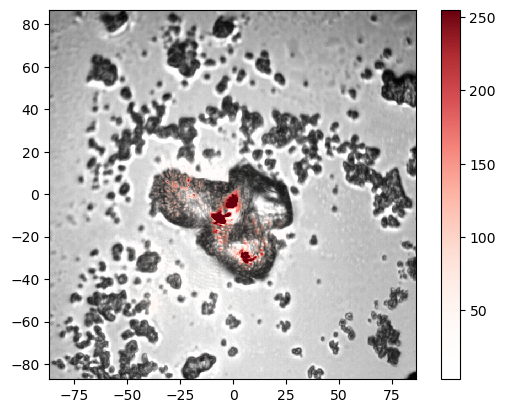

In [36]:
# Configure scan and preview scan area
# 3ms integration time
filename = "diamondCaroteneIPA_GSDev1a-1255.8_OEland1075.7-69mW_1mV1ms_forReal2_6tLIA_pos30" 
sample_dir = "GSDev1a_inline"

t_LIA = 1*u.ms
nx, ny      =   200   ,   200 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(6*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=4*u.ms)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_GSDev1a_inline_2025-04-13-23-54-26\GalvoScan_diamondCaroteneIPA_GSDev1a-1255.8_OEland1075.7-69mW_1mV1ms_forReal2_6tLIA_pos30_2025-04-19-01-20-44.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 240.00 second
start time: Sat Apr 19 01:20:46 2025
stop time: Sat Apr 19 01:24:46 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-lis

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


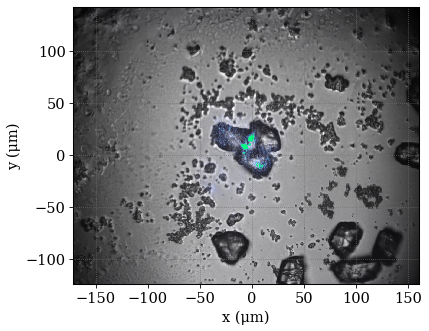

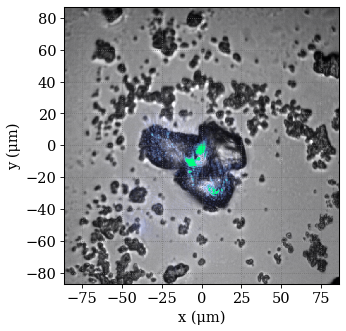

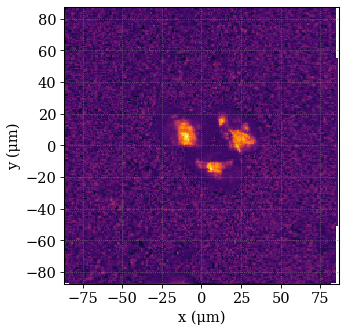

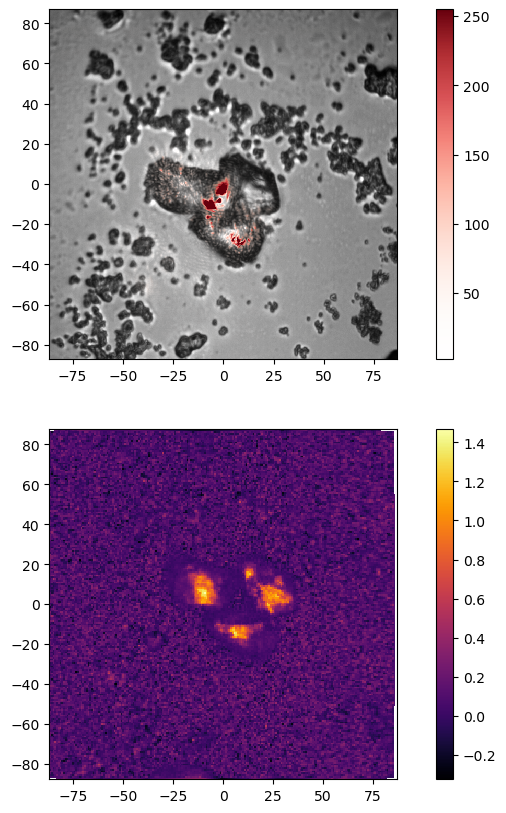

In [37]:
ds0 = collect_wfscan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,name=filename,sample_dir=sample_dir,wf_exposure_time=3*u.ms)
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno)

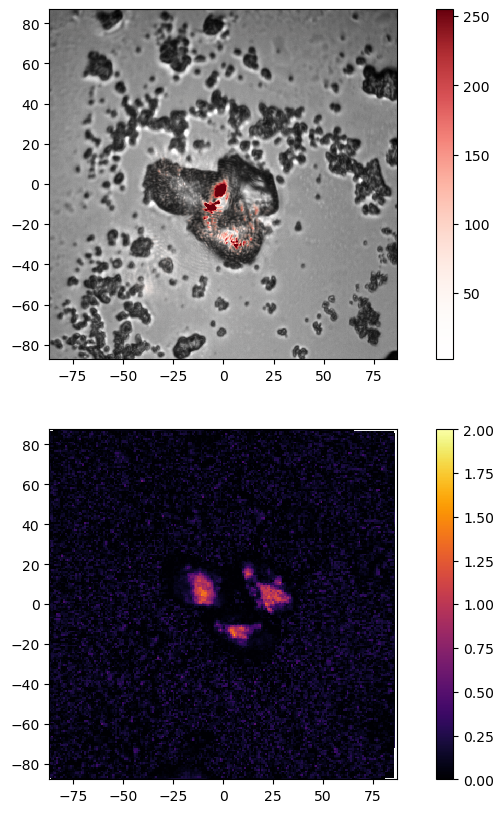

In [29]:
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=2)

In [6]:
def plot_scan_data(ds,wf_cmap=cm.gray,laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=None, vmax=None):
    """
    Plot 2x1 subplots with [0] laser spot superimposed on cropped widefield image, and [1] SRS image
    :param ds: from collect_scan()
    :return: fig with (2) subplots
    """
    laser_cmap = transparent_cmap(laser_cmap)
    fig, ax = plt.subplots(2,1, figsize = (10,10))
    
    # Find wf image indices corresponding to scan area, add manual offset to match scan area
    i_xmax, i_xmin, i_ymax, i_ymin = wf_img_inds(ds)
    x_off = 0#10
    y_off = 0#40
    i_xmax += x_off
    i_xmin += x_off
    i_ymin += y_off
    i_ymax += y_off
 
    # [0] Laser spot + cropped widefield image
    im0 = ax[0].pcolormesh(ds["y_img"][i_ymin:i_ymax], ds["x_img"][i_xmin:i_xmax],
                              ds["wf_img"][i_xmax:i_xmin:-1, i_ymin:i_ymax], cmap=wf_cmap)
    im1 = ax[0].pcolormesh(ds["y_img"][i_ymin:i_ymax], ds["x_img"][i_xmin:i_xmax],
                              ds["laser_spot_img"][i_xmax:i_xmin:-1, i_ymin:i_ymax], cmap=laser_cmap)
    cb0 = plt.colorbar(im1, ax=ax[0])
    ax[0].set_aspect("equal")

    # [1] SRS (galvo) image
    p0 = ax[1].pcolormesh(ds["y"].m, ds["x"].m, np.flipud(np.transpose(ds["Vsrs_g"].m)), cmap=srs_cmap, vmin=vmin, vmax=vmax)
    cb1 = plt.colorbar(p0, ax=ax[1])
    ax[1].set_aspect("equal")

    plt.show()
    return fig

# Manual widefield image+ scan

scan time: 900.00 second


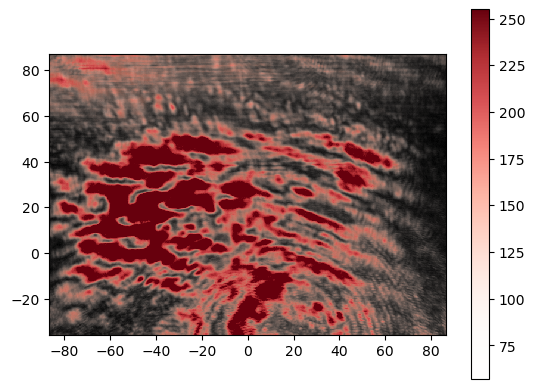

In [14]:
sample_dir= "GSDev1a" 
filename = "diamondPowder_GSDev1a-1256.8_OEland1075.6-71mW_300uV3ms_manual"

t_LIA = 3*u.ms
nx, ny      =   150   ,   150 #500          ,       500
ΔVx, ΔVy    =   1.0*u.volt   ,   1.0*u.volt #1.0*u.volt    ,      1.0*u.volt # 0.8*u.volt
fsamp       =   (1/(4*t_LIA)).to(u.Hz)#1000*u.Hz

fig = preview_scan_area(nx, ny, ΔVx, ΔVy, fsamp=fsamp, exposure_time=81*u.ms)

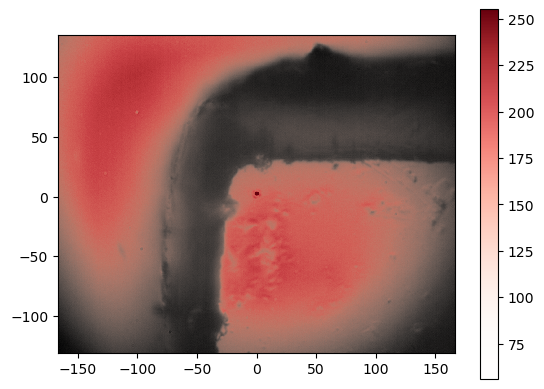

In [4]:
# Take laser spot and widefield image
wf_img, laser_spot_img = wf_and_laser_spot_images(exposure_time=81*u.ms)
fig = plot_laser_widefield_img(wf_img, laser_spot_img)

saving data to: 
C:\Users\euyehara\Documents\data\srs_microscope\Sample_diamond_SRL_GSDev1a_OEland1075.6-70mW_Nikon20x_2025-03-21-20-29-02\GalvoScan_Dev1a-1255.81_300uV3ms_1V150N_maxUp_2025-03-21-22-26-34.h5
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
scan time: 900.00 second
start time: Fri Mar 21 22:26:34 2025
stop time: Fri Mar 21 22:41:34 2025
dumping item: Dev1/ao0
dumping item: Dev1/ao1
dumping item: Dev1/ao2
dumping item: Dev1/ao3
dumping item: Dev1/ai0
dumping item: Dev1/ai2
dumping item: Dev1/ai3
dumping item: t
dumping item: Vx
dumping item: Vy
dumping item: dx_dVx
non-array, non-list item with 

C:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


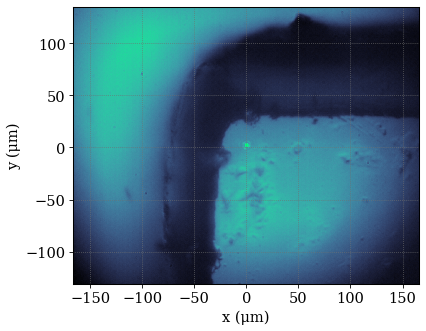

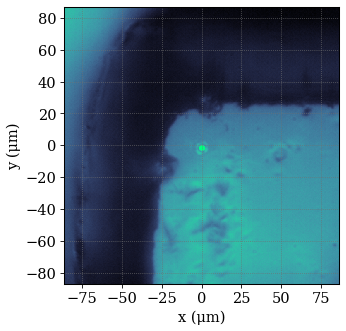

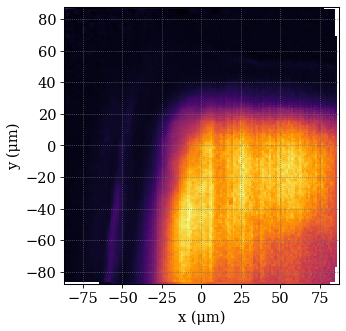

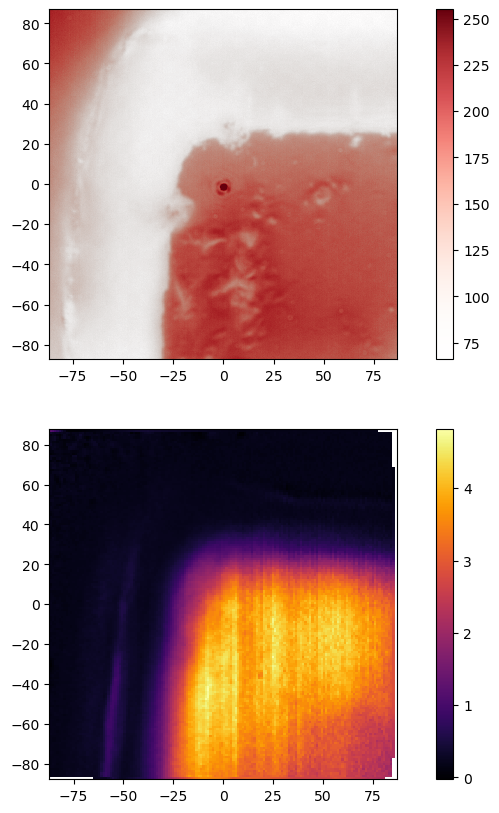

In [15]:
ds0 = collect_scan(nx,ny,ΔVx,ΔVy,Vx0,Vy0,fsamp,wf_img,laser_spot_img,name=filename,sample_dir=sample_dir)
fig = plot_scan_data(ds0, wf_cmap=cm.binary, laser_cmap=cm.Reds, srs_cmap=cm.inferno)